# Comparativa de Modelos — Sistema de Navegación Asistida
## Taller de Grado I
Lee automáticamente los CSV de resumen de cada modelo y genera tablas y gráficas comparativas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Configuración ─────────────────────────────────────────────────────────────
OUTPUT_DIR = Path(r"F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation\output")

# Modelos a comparar (carpeta → nombre display)
MODELOS = {
    "yolo26n":      {"nombre": "YOLO26n",       "tipo": "Detector",    "color": "#2196F3"},
    "yolo26n_seg":  {"nombre": "YOLO26n-seg",   "tipo": "Detector",    "color": "#03A9F4"},
    "yolov8n":      {"nombre": "YOLOv8n",       "tipo": "Detector",    "color": "#00BCD4"},
    "ddrnet":       {"nombre": "DDRNet (B3)",   "tipo": "Segmentador", "color": "#FF5722"},
    "bisenetv2":    {"nombre": "BiSeNetV2 (B2)","tipo": "Segmentador", "color": "#FF9800"},
    "segformer_b0": {"nombre": "SegFormer-B0",  "tipo": "Segmentador", "color": "#FFC107"},
}

# Criterios de validación del documento
CRITERIO_LAT_MS  = 300   # latencia < 300ms
CRITERIO_FPS     = 15    # FPS >= 15
CRITERIO_STD_PCT = 25    # std < 20% del promedio

print(f"Directorio de salida: {OUTPUT_DIR}")
print(f"Modelos configurados: {list(MODELOS.keys())}")

Directorio de salida: F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation\output
Modelos configurados: ['yolo26n', 'yolo26n_seg', 'yolov8n', 'ddrnet', 'bisenetv2', 'segformer_b0']


In [4]:
# ── Leer CSVs de resumen ──────────────────────────────────────────────────────

def leer_resumen(carpeta: Path) -> dict:
    """Lee el CSV de resumen de un modelo y extrae las métricas clave."""
    csvs = list(carpeta.glob("*_resumen.csv"))
    if not csvs:
        print(f"  [!] Sin CSV en {carpeta.name}")
        return None

    # Tomar el más reciente si hay varios
    csv_path = sorted(csvs)[-1]
    print(f"  Leyendo: {csv_path.name}")

    # Leer líneas de comentario (métricas de sistema y criterios)
    meta = {}
    criterios = {}
    data_lines = []

    with open(csv_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith("# Frames,"):
                meta["frames"] = int(line.split(",")[1])
            elif line.startswith("# gpu,"):
                meta["gpu"] = line.split(",")[1]
            elif line.startswith("# Lat <300ms,"):
                criterios["lat"] = line.split(",")[1]
            elif line.startswith("# FPS >=15,"):
                criterios["fps"] = line.split(",")[1]
            elif line.startswith("# Estab <20%,"):
                criterios["estab"] = line.split(",")[1]
            elif not line.startswith("#") and line:
                data_lines.append(line)

    # Parsear tabla de estadísticas
    metricas = {}
    if len(data_lines) > 1:  # primera línea es encabezado
        header = data_lines[0].split(",")
        for row in data_lines[1:]:
            vals = row.split(",")
            if len(vals) >= 3:
                nombre = vals[0]
                try:
                    metricas[nombre] = {
                        h: float(v) for h, v in zip(header[1:], vals[1:])
                        if v.strip()
                    }
                except ValueError:
                    pass

    return {
        "meta":      meta,
        "criterios": criterios,
        "metricas":  metricas,
        "csv":       csv_path.name,
    }


# Leer todos los modelos
resultados = {}
for carpeta_nombre, info in MODELOS.items():
    carpeta = OUTPUT_DIR / carpeta_nombre
    if carpeta.exists():
        res = leer_resumen(carpeta)
        if res:
            resultados[carpeta_nombre] = res
    else:
        print(f"  [!] Carpeta no encontrada: {carpeta}")

print(f"\nModelos cargados: {list(resultados.keys())}")

  Leyendo: acera_test_resumen.csv
  Leyendo: acera_test_resumen.csv
  Leyendo: acera_test_resumen.csv
  Leyendo: acera_test_resumen.csv
  Leyendo: acera_test_resumen.csv
  Leyendo: acera_test_15fps_resumen.csv

Modelos cargados: ['yolo26n', 'yolo26n_seg', 'yolov8n', 'ddrnet', 'bisenetv2', 'segformer_b0']


In [5]:
# ── Construir DataFrame resumen ───────────────────────────────────────────────

filas = []
for key, info in MODELOS.items():
    if key not in resultados:
        continue
    res = resultados[key]
    m   = res["metricas"]
    cr  = res["criterios"]

    def get(metrica, stat):
        return m.get(metrica, {}).get(stat, np.nan)

    fila = {
        "Modelo":        info["nombre"],
        "Tipo":          info["tipo"],
        "Frames":        res["meta"].get("frames", "-"),
        "FPS media":     round(get("fps_instantaneo", "media"), 1),
        "FPS min":       round(get("fps_instantaneo", "min"),   1),
        "Lat media (ms)": round(get("latencia_ms", "media"),    1),
        "Lat std (ms)":  round(get("latencia_ms", "std"),       1),
        "Lat p95 (ms)":  round(get("latencia_ms", "p95"),       1),
        "RAM pico (GB)":  round(get("ram_gb", "max"),           2),
        "VRAM pico (MB)": round(get("gpu_mb", "max"),           0),
        "Sidewalk %":    round(get("pct_sidewalk", "media"),    1) if "pct_sidewalk" in m else "-",
        "✅ Lat <300ms":  cr.get("lat", "-"),
        "✅ FPS >=15":    cr.get("fps", "-"),
        "✅ Estab <20%": cr.get("estab", "-"),
    }
    filas.append(fila)

df = pd.DataFrame(filas)
df = df.set_index("Modelo")

print("\n=== TABLA COMPARATIVA COMPLETA ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df.to_string())


=== TABLA COMPARATIVA COMPLETA ===
                       Tipo  Frames  FPS media  FPS min  Lat media (ms)  Lat std (ms)  Lat p95 (ms)  RAM pico (GB)  VRAM pico (MB) Sidewalk % ✅ Lat <300ms ✅ FPS >=15 ✅ Estab <20%
Modelo                                                                                                                                                                            
YOLO26n            Detector   17983       95.7      2.1            10.9           4.2          15.2          19.29          2642.0          -       CUMPLE     CUMPLE    NO CUMPLE
YOLO26n-seg        Detector   17983       73.3      1.0            14.6           9.0          22.6          20.35          2944.0          -       CUMPLE     CUMPLE    NO CUMPLE
YOLOv8n            Detector   17983       92.8      2.1            11.8           5.2          17.0          19.93          2605.0          -       CUMPLE     CUMPLE    NO CUMPLE
DDRNet (B3)     Segmentador   17983       29.7      5.1            34

In [6]:
# ── Tabla por bloques ─────────────────────────────────────────────────────────

print("\n=== BLOQUE A — DETECTORES ===")
df_det = df[df["Tipo"] == "Detector"]
print(df_det[["Frames","FPS media","FPS min",
              "Lat media (ms)","Lat p95 (ms)",
              "RAM pico (GB)","VRAM pico (MB)",
              "✅ Lat <300ms","✅ FPS >=15"]].to_string())

print("\n=== BLOQUE B — SEGMENTADORES ===")
df_seg = df[df["Tipo"] == "Segmentador"]
print(df_seg[["Frames","FPS media","FPS min",
              "Lat media (ms)","Lat p95 (ms)",
              "RAM pico (GB)","VRAM pico (MB)","Sidewalk %",
              "✅ Lat <300ms","✅ FPS >=15"]].to_string())


=== BLOQUE A — DETECTORES ===
             Frames  FPS media  FPS min  Lat media (ms)  Lat p95 (ms)  RAM pico (GB)  VRAM pico (MB) ✅ Lat <300ms ✅ FPS >=15
Modelo                                                                                                                      
YOLO26n       17983       95.7      2.1            10.9          15.2          19.29          2642.0       CUMPLE     CUMPLE
YOLO26n-seg   17983       73.3      1.0            14.6          22.6          20.35          2944.0       CUMPLE     CUMPLE
YOLOv8n       17983       92.8      2.1            11.8          17.0          19.93          2605.0       CUMPLE     CUMPLE

=== BLOQUE B — SEGMENTADORES ===
                Frames  FPS media  FPS min  Lat media (ms)  Lat p95 (ms)  RAM pico (GB)  VRAM pico (MB) Sidewalk % ✅ Lat <300ms ✅ FPS >=15
Modelo                                                                                                                                    
DDRNet (B3)      17983       29.

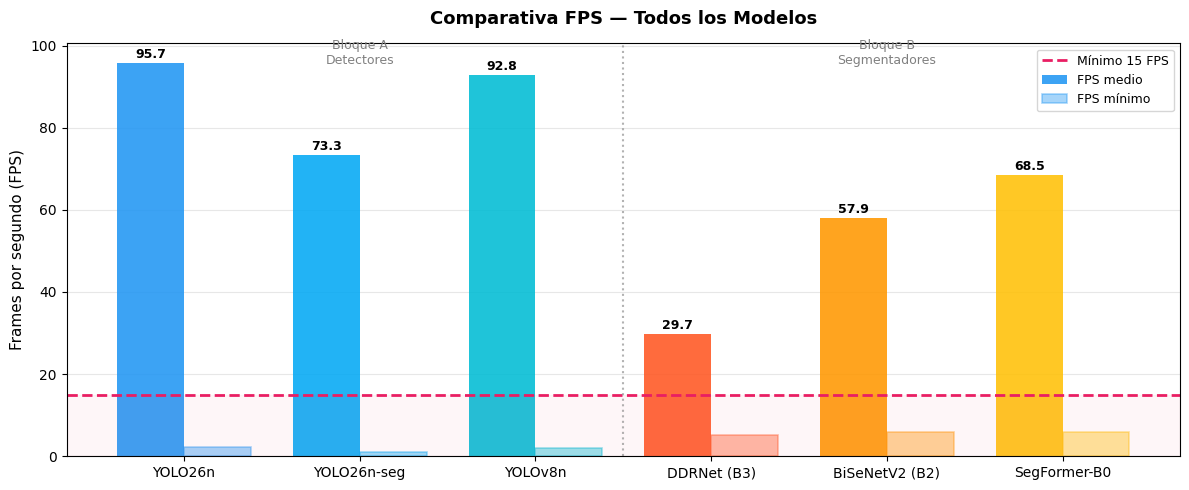

Guardada: comparativa_fps.png


In [7]:
# ── Gráfica 1: FPS comparativo ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

nombres  = [MODELOS[k]["nombre"] for k in resultados]
colores  = [MODELOS[k]["color"]  for k in resultados]
fps_vals = [resultados[k]["metricas"].get("fps_instantaneo",{}).get("media", 0)
            for k in resultados]
fps_min  = [resultados[k]["metricas"].get("fps_instantaneo",{}).get("min", 0)
            for k in resultados]

x      = np.arange(len(nombres))
ancho  = 0.38
bars1  = ax.bar(x - ancho/2, fps_vals, ancho, color=colores, alpha=0.88, label="FPS medio")
bars2  = ax.bar(x + ancho/2, fps_min,  ancho, color=colores, alpha=0.40,
                edgecolor=colores, linewidth=1.2, label="FPS mínimo")

ax.axhline(CRITERIO_FPS, color="#E91E63", lw=2, ls="--", label=f"Mínimo {CRITERIO_FPS} FPS")
ax.axhspan(0, CRITERIO_FPS, alpha=0.04, color="#E91E63")

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Separador entre detectores y segmentadores
n_det = sum(1 for k in resultados if MODELOS[k]["tipo"] == "Detector")
if n_det > 0 and n_det < len(nombres):
    ax.axvline(n_det - 0.5, color="gray", ls=":", lw=1.5, alpha=0.6)
    ax.text(n_det/2 - 0.5,    ax.get_ylim()[1]*0.95, "Bloque A\nDetectores",
            ha="center", fontsize=9, color="gray")
    ax.text(n_det + (len(nombres)-n_det)/2 - 0.5, ax.get_ylim()[1]*0.95,
            "Bloque B\nSegmentadores", ha="center", fontsize=9, color="gray")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("Frames por segundo (FPS)", fontsize=11)
ax.set_title("Comparativa FPS — Todos los Modelos", fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"comparativa_fps.png", dpi=150)
plt.show()
print("Guardada: comparativa_fps.png")

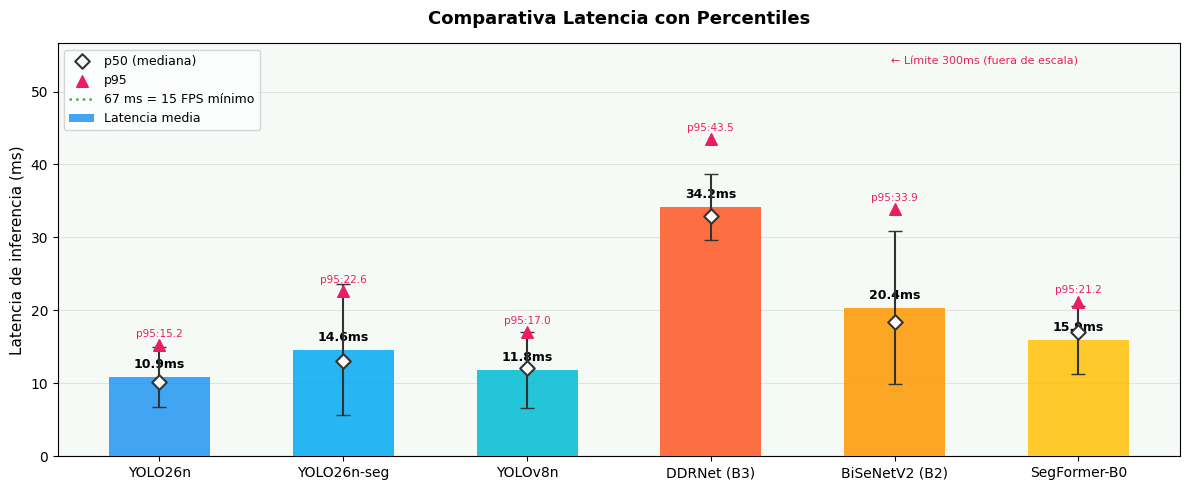

Guardada: comparativa_latencia.png


In [13]:
# ── Gráfica 2: Latencia con percentiles ──────────────────────────────────────
# Escala Y dinámica basada en los datos reales, no en el límite de 300ms

fig, ax = plt.subplots(figsize=(12, 5))

lat_media = [resultados[k]["metricas"].get("latencia_ms",{}).get("media", 0) for k in resultados]
lat_std   = [resultados[k]["metricas"].get("latencia_ms",{}).get("std",   0) for k in resultados]
lat_p95   = [resultados[k]["metricas"].get("latencia_ms",{}).get("p95",   0) for k in resultados]
lat_p50   = [resultados[k]["metricas"].get("latencia_ms",{}).get("p50",   0) for k in resultados]

bars = ax.bar(x, lat_media, 0.55, color=colores, alpha=0.85, label="Latencia media", zorder=3)
ax.scatter(x, lat_p50, marker="D", s=55, color="white", edgecolors="#333", lw=1.5,
           zorder=5, label="p50 (mediana)")
ax.scatter(x, lat_p95, marker="^", s=70, color="#E91E63", zorder=5, label="p95")
ax.errorbar(x, lat_media, yerr=lat_std, fmt="none", color="#333", capsize=5, lw=1.5, zorder=4)

# Escala Y dinámica: max de p95 + 20% de margen
y_max = max(lat_p95) * 1.30
ax.set_ylim(0, y_max)

# Línea de 15 FPS (67ms) — siempre visible
lim_fps = 1000 / CRITERIO_FPS
ax.axhline(lim_fps, color="#4CAF50", lw=1.8, ls=":",
           label=f"{lim_fps:.0f} ms = {CRITERIO_FPS} FPS mínimo", zorder=2)
ax.axhspan(0, lim_fps, alpha=0.05, color="#4CAF50", zorder=1)

# Línea de 300ms solo si entra en la escala
if CRITERIO_LAT_MS < y_max:
    ax.axhline(CRITERIO_LAT_MS, color="#E91E63", lw=1.8, ls="--",
               label=f"Límite {CRITERIO_LAT_MS} ms", zorder=2)
else:
    ax.annotate(f"← Límite {CRITERIO_LAT_MS}ms (fuera de escala)",
                xy=(len(nombres)-1, y_max*0.95), fontsize=8, color="#E91E63",
                ha="right")

# Etiquetas encima de cada barra
for bar, val, p95 in zip(bars, lat_media, lat_p95):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + y_max*0.015,
            f"{val:.1f}ms", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    ax.text(bar.get_x()+bar.get_width()/2,
            p95 + y_max*0.015,
            f"p95:{p95:.1f}", ha="center", va="bottom",
            fontsize=7.5, color="#E91E63")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("Latencia de inferencia (ms)", fontsize=11)
ax.set_title("Comparativa Latencia con Percentiles", fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9, loc="upper left")
ax.yaxis.grid(True, alpha=0.3, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"comparativa_latencia.png", dpi=150)
plt.show()
print("Guardada: comparativa_latencia.png")

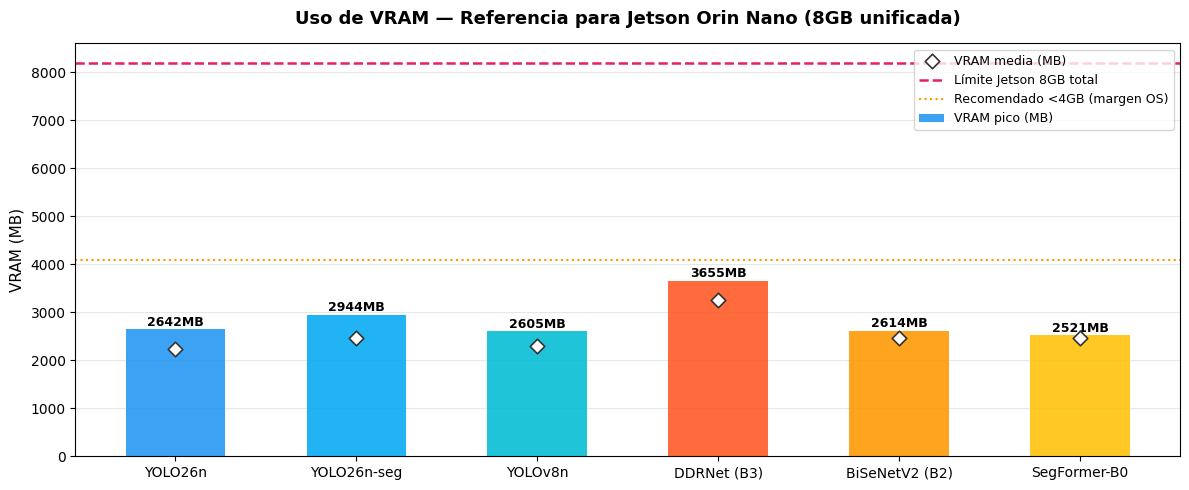

Guardada: comparativa_vram.png


In [10]:
# ── Gráfica 3: VRAM ───────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

vram_vals = [resultados[k]["metricas"].get("gpu_mb",{}).get("max", 0) for k in resultados]
vram_med  = [resultados[k]["metricas"].get("gpu_mb",{}).get("media", 0) for k in resultados]

bars = ax.bar(x, vram_vals, 0.55, color=colores, alpha=0.88, label="VRAM pico (MB)")
ax.scatter(x, vram_med, marker="D", s=55, color="white",
           edgecolors="#333", lw=1.2, zorder=5, label="VRAM media (MB)")

# Línea referencia Jetson Orin Nano — 8GB compartida CPU+GPU
ax.axhline(8192, color="#E91E63", lw=1.8, ls="--", label="Límite Jetson 8GB total")
ax.axhline(4096, color="#FF9800", lw=1.5, ls=":",  label="Recomendado <4GB (margen OS)")

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{bar.get_height():.0f}MB", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=10)
ax.set_ylabel("VRAM (MB)", fontsize=11)
ax.set_title("Uso de VRAM — Referencia para Jetson Orin Nano (8GB unificada)",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"comparativa_vram.png", dpi=150)
plt.show()
print("Guardada: comparativa_vram.png")

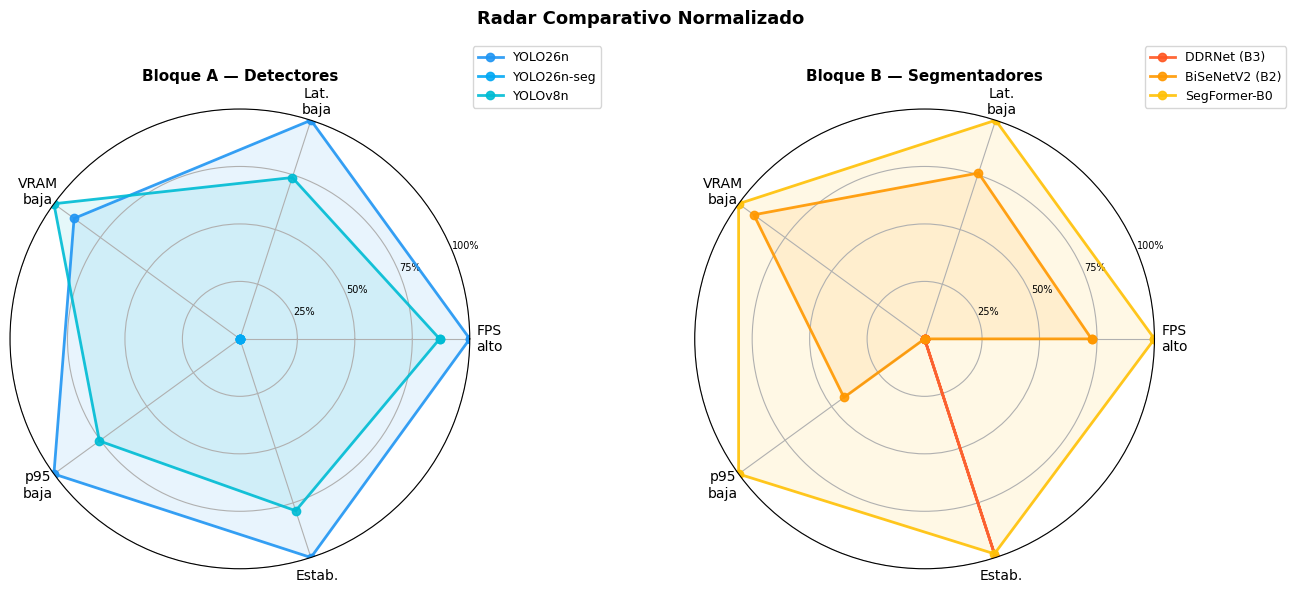

Guardada: comparativa_radar.png


In [11]:
# ── Gráfica 4: Radar normalizado ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))

categorias = ["FPS\nalto", "Lat.\nbaja", "VRAM\nbaja", "p95\nbaja", "Estab."]
N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]

def normalizar(arr, invert=False):
    arr = np.array(arr, dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn: return np.ones_like(arr) * 0.5
    n = (arr - mn) / (mx - mn)
    return 1 - n if invert else n

for ax_idx, (tipo, titulo) in enumerate([("Detector","Bloque A — Detectores"),
                                           ("Segmentador","Bloque B — Segmentadores")]):
    ax = axes[ax_idx]
    keys_tipo = [k for k in resultados if MODELOS[k]["tipo"] == tipo]
    if not keys_tipo:
        ax.set_title(f"{titulo}\n(sin datos)"); continue

    fps_n  = normalizar([resultados[k]["metricas"].get("fps_instantaneo",{}).get("media",0) for k in keys_tipo])
    lat_n  = normalizar([resultados[k]["metricas"].get("latencia_ms",{}).get("media",0) for k in keys_tipo], invert=True)
    vram_n = normalizar([resultados[k]["metricas"].get("gpu_mb",{}).get("max",0) for k in keys_tipo], invert=True)
    p95_n  = normalizar([resultados[k]["metricas"].get("latencia_ms",{}).get("p95",0) for k in keys_tipo], invert=True)
    std_n  = normalizar([resultados[k]["metricas"].get("latencia_ms",{}).get("std",0) for k in keys_tipo], invert=True)

    for i, k in enumerate(keys_tipo):
        vals = [fps_n[i], lat_n[i], vram_n[i], p95_n[i], std_n[i]]
        vals += vals[:1]
        color = MODELOS[k]["color"]
        ax.plot(angulos, vals, "o-", lw=2, color=color,
                label=MODELOS[k]["nombre"], alpha=0.9)
        ax.fill(angulos, vals, alpha=0.10, color=color)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["25%","50%","75%","100%"], fontsize=7)
    ax.set_title(titulo, fontsize=11, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=9)

fig.suptitle("Radar Comparativo Normalizado", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"comparativa_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardada: comparativa_radar.png")

In [12]:
# ── Conclusión automática ─────────────────────────────────────────────────────

print("=" * 60)
print("  CONCLUSIÓN — SELECCIÓN DE MODELOS")
print("=" * 60)

# Filtrar los que cumplen criterios
def cumple(key):
    cr = resultados[key]["criterios"]
    return cr.get("lat") == "CUMPLE" and cr.get("fps") == "CUMPLE"

detectores   = [k for k in resultados if MODELOS[k]["tipo"] == "Detector"   and cumple(k)]
segmentadores = [k for k in resultados if MODELOS[k]["tipo"] == "Segmentador" and cumple(k)]

print("\n  BLOQUE A — Detectores que cumplen criterios:")
for k in detectores:
    fps = resultados[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
    lat = resultados[k]["metricas"].get("latencia_ms",{}).get("media",0)
    print(f"    ✅ {MODELOS[k]['nombre']:20s}  FPS={fps:.1f}  Lat={lat:.1f}ms")

if detectores:
    ganador_det = max(detectores,
                      key=lambda k: resultados[k]["metricas"].get("fps_instantaneo",{}).get("media",0))
    print(f"\n  🏆 Ganador Bloque A: {MODELOS[ganador_det]['nombre']}")

print("\n  BLOQUE B — Segmentadores que cumplen criterios:")
for k in segmentadores:
    fps = resultados[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
    lat = resultados[k]["metricas"].get("latencia_ms",{}).get("media",0)
    sw  = resultados[k]["metricas"].get("pct_sidewalk",{}).get("media",0)
    print(f"    ✅ {MODELOS[k]['nombre']:20s}  FPS={fps:.1f}  Lat={lat:.1f}ms  sidewalk={sw:.1f}%")

if segmentadores:
    # Ganador: mejor sidewalk% entre los que cumplen FPS
    ganador_seg = max(segmentadores,
                      key=lambda k: resultados[k]["metricas"].get("pct_sidewalk",{}).get("media",0))
    print(f"\n  🏆 Ganador Bloque B: {MODELOS[ganador_seg]['nombre']}")

print()
no_cumplen = [k for k in resultados if not cumple(k)]
if no_cumplen:
    print("  ❌ No cumplen criterios:")
    for k in no_cumplen:
        fps = resultados[k]["metricas"].get("fps_instantaneo",{}).get("media",0)
        lat = resultados[k]["metricas"].get("latencia_ms",{}).get("media",0)
        print(f"     {MODELOS[k]['nombre']:20s}  FPS={fps:.1f}  Lat={lat:.1f}ms")

print("\n" + "=" * 60)

  CONCLUSIÓN — SELECCIÓN DE MODELOS

  BLOQUE A — Detectores que cumplen criterios:
    ✅ YOLO26n               FPS=95.7  Lat=10.9ms
    ✅ YOLO26n-seg           FPS=73.3  Lat=14.6ms
    ✅ YOLOv8n               FPS=92.8  Lat=11.8ms

  🏆 Ganador Bloque A: YOLO26n

  BLOQUE B — Segmentadores que cumplen criterios:
    ✅ DDRNet (B3)           FPS=29.7  Lat=34.2ms  sidewalk=2.7%
    ✅ BiSeNetV2 (B2)        FPS=57.9  Lat=20.4ms  sidewalk=1.3%
    ✅ SegFormer-B0          FPS=68.5  Lat=15.9ms  sidewalk=3.2%

  🏆 Ganador Bloque B: SegFormer-B0




In [14]:
# ── Exportar tabla resumen a CSV ──────────────────────────────────────────────

out_csv = OUTPUT_DIR / "tabla_comparativa_final.csv"
df.to_csv(out_csv, encoding="utf-8")
print(f"Tabla exportada: {out_csv}")
print("\nArchivos generados:")
for f in ["comparativa_fps.png", "comparativa_latencia.png",
          "comparativa_memoria.png", "comparativa_radar.png",
          "tabla_comparativa_final.csv"]:
    p = OUTPUT_DIR / f
    estado = "✅" if p.exists() else "❌"
    print(f"  {estado} {f}")

Tabla exportada: F:\Archivos\Semestres UCB\Semestre_1_2026\Taller_Grado_1\Assistive-Navigation\output\tabla_comparativa_final.csv

Archivos generados:
  ✅ comparativa_fps.png
  ✅ comparativa_latencia.png
  ✅ comparativa_memoria.png
  ✅ comparativa_radar.png
  ✅ tabla_comparativa_final.csv
